In [ ]:
#LE OS ARQUIVOS E ADICIONA OS LOGS DE ARQUIVOS QUE FORAM PROCESSADOS SEPARADAMENTE

import pandas as pd


# Caminho do arquivo CSV (substitua ou pressione Enter para usar 'data.csv')
path = "/home/amandaventurin/Downloads/redes-neurais-perceptron-EP1IA/analise_hiperparametros/resultado_variacao_n_hidden.csv"

# Lê o CSV para um DataFrame e mostra as primeiras linhas
df = pd.read_csv(path)


#df com apenas a coluna n_hidden e alpha
#df = df[["alpha", "tempo_execucao_segundos", "acuracia_teste", "epocas_executadas"]]
df = df[df["n_hidden"] != 70]

novas_linhas = pd.DataFrame({
    "n_hidden": [10, 20, 40, 50, 60, 70],
    "tempo_execucao_segundos": [160.32, 402.89, 473.84, 1413.9338, 481.37, 1350.33],
    "erro_treinamento_final": [1.170498, 1.409401, 1.724130, 1.69, 1.652909, 1.67],
    "epocas_executadas": [264, 373, 223, 464, 153, 244]
})

df = pd.concat([df, novas_linhas], ignore_index=True)
df = df[["n_hidden", "tempo_execucao_segundos", "epocas_executadas"]]
df = df.sort_values(
    by="n_hidden",
    ascending=True
)
display(df)


,n_hidden,tempo_execucao_segundos,epocas_executadas
3,10,160.320000,264
4,20,402.890000,373
0,30,868.136862,457
5,40,473.840000,223
6,50,1413.933800,464
7,60,481.370000,153
8,70,1350.330000,244
2,80,4161.973964,178
1,90,5649.944399,215


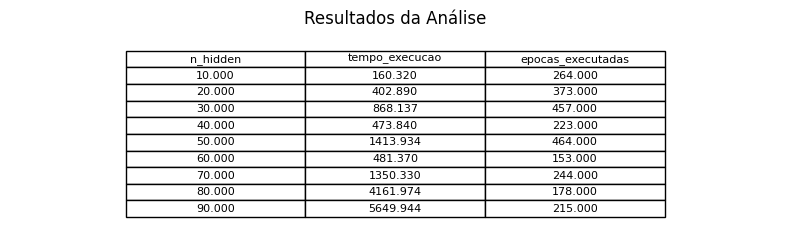

In [ ]:
#FORMATA TABELA ANALITICA DE RESULTADOS

import matplotlib.pyplot as plt

df = df.rename(
    columns={
        "tempo_execucao_segundos": "tempo_execucao"
    }
)

# Formata todos os valores numéricos com 2 casas decimais
df_formatado = df.copy()

for coluna in df_formatado.select_dtypes(include=["float", "float64", "int64"]).columns:
    df_formatado[coluna] = df_formatado[coluna].map(lambda x: f"{x:.3f}")

# Figura menor
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')

tabela = ax.table(
    cellText=df_formatado.values,
    colLabels=df_formatado.columns,
    cellLoc='center',
    loc='center'
)

# Fonte menor
tabela.auto_set_font_size(False)
tabela.set_fontsize(8)

# Reduz altura e largura das células
tabela.scale(0.7, 1)

plt.title(
    "Resultados da Análise",
    fontsize=12,
    pad=10
)

plt.tight_layout()
plt.show()



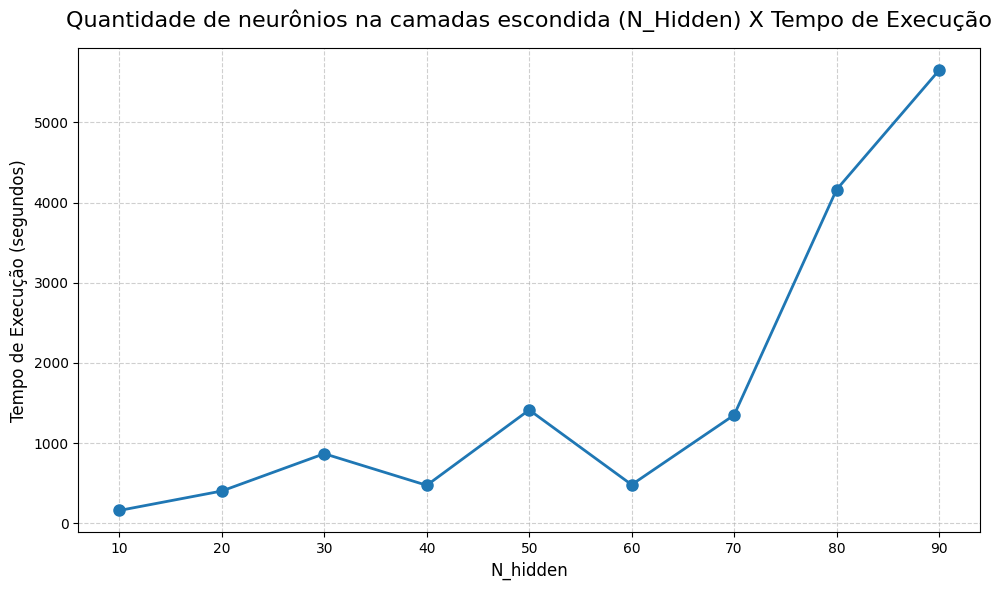

In [ ]:
#CRIAÇÃO DE TABELA DE LINHAS

import matplotlib.pyplot as plt

# Ordena pelo alpha
df = df.sort_values("n_hidden")

# ==========================
# Configurações visuais
# ==========================

plt.figure(figsize=(10, 6))

plt.plot(
    df["n_hidden"],
    df["tempo_execucao"],
    marker="o",
    linewidth=2,
    markersize=8
)
#plt.xscale("log")
plt.title(
    "Quantidade de neurônios na camadas escondida (N_Hidden) X Tempo de Execução",
    fontsize=16,
    pad=15
)

plt.xlabel(
    "N_hidden",
    fontsize=12
)

plt.ylabel(
    "Tempo de Execução (segundos)",
    fontsize=12
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)

plt.xticks(df["n_hidden"])
plt.xticks(
    df["n_hidden"],
    [str(x) for x in df["n_hidden"]]
)
plt.tight_layout()

plt.show()
